# De donde salen las perdidas

Analisis por operacion del backtest de reversion corregido (`back_normal_reversion.py`).

El backtest exporta una fila por operacion a `Backtest/trades/`. Para regenerarlas:

```
cd Backtest
python back_normal_reversion.py
```

**Ojo con el directorio.** `PRE_CALC_DIR` y `TRADES_DIR` son relativos al CWD: hay
que lanzarlo desde `Backtest/`. Lanzado desde `MT5connection/` ignora las 136
semanas cacheadas y reoptimiza todo con parametros distintos.

La pregunta que responde este notebook: el PnL neto de los tres años es negativo,
pero **no esta repartido**. Casi todo vive en un solo tipo de salida.

In [12]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Paleta categorica validada, slots 1 y 2 (CVD dE 9.1 en superficie clara).
# La identidad la lleva el color; los numeros y etiquetas van en tinta, nunca
# en el color de la serie.
C_SENAL   = "#2a78d6"   # salidas por señal
C_VIERNES = "#eb6834"   # cierre forzado del viernes
SURFACE, INK, INK_2, GRID, ZERO = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2df", "#9a9995"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_2,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 12, "figure.dpi": 110,
    "legend.frameon": False,
})

usd = FuncFormatter(lambda x, _: f"${x:,.0f}")

def titular(ax, titulo, sub=None):
    """Titulo a la izquierda con subtitulo opcional, ambos en tinta."""
    ax.set_title(titulo, loc="left", pad=22 if sub else 10, color=INK, fontweight="semibold")
    if sub:
        ax.text(0, 1.03, sub, transform=ax.transAxes, fontsize=9, color=INK_2, va="bottom")
    ax.set_axisbelow(True)
    return ax

## Cargar las operaciones

In [13]:
TRADES = "trades_epoch"   # "trades" para la corrida con los parametros viejos

def cargar(carpeta=TRADES):
    filas = []
    for ruta in sorted(glob.glob(os.path.join(carpeta, "*.csv"))):
        partes = os.path.basename(ruta)[:-4].split("_")
        t = pd.read_csv(ruta)
        t["lado"] = partes[-1].upper()
        t["anio"] = int(partes[-2])
        filas.append(t)
    if not filas:
        raise FileNotFoundError(
            f"No hay CSVs en '{carpeta}/'. Lanza back_normal_reversion.py desde Backtest/.")
    d = pd.concat(filas, ignore_index=True)
    for c in ("fecha_entrada", "fecha_salida"):
        d[c] = pd.to_datetime(d[c])
    d["dur_h"]   = (d.fecha_salida - d.fecha_entrada).dt.total_seconds() / 3600
    d["dia_ent"] = d.fecha_entrada.dt.dayofweek
    return d.sort_values("fecha_salida").reset_index(drop=True)

ops = cargar()
print(f"{len(ops):,} operaciones  |  {ops.anio.min()}-{ops.anio.max()}  |  "
      f"PnL neto ${ops.pnl_neto_usd.sum():,.2f}")
ops.tipo.value_counts()

1,293 operaciones  |  2024-2026  |  PnL neto $-3,878.18


tipo
Cierre_Señal      1159
Cierre_Viernes     134
Name: count, dtype: int64

## Resumen por tipo de salida

Vista de tabla — mismos datos que las graficas que siguen, para leerlos sin depender del color.

In [14]:
resumen = (ops.groupby("tipo")
             .agg(operaciones=("pnl_neto_usd", "size"),
                  pnl_total=("pnl_neto_usd", "sum"),
                  pnl_medio=("pnl_neto_usd", "mean"),
                  pct_ganadoras=("pnl_neto_usd", lambda s: (s > 0).mean() * 100),
                  dur_mediana_h=("dur_h", "median"))
             .round(2)
             .sort_values("pnl_total"))
resumen

,operaciones,pnl_total,pnl_medio,pct_ganadoras,dur_mediana_h
tipo,,,,,
Cierre_Viernes,134,-10483.89,-78.24,10.45,12.78
Cierre_Señal,1159,6605.71,5.70,76.36,2.93


## 1. La divergencia

Dos curvas de PnL acumulado sobre las mismas operaciones: una cuenta todo, la otra
cuenta solo las salidas por señal. La distancia entre ambas es el coste del cierre
forzado de los viernes.

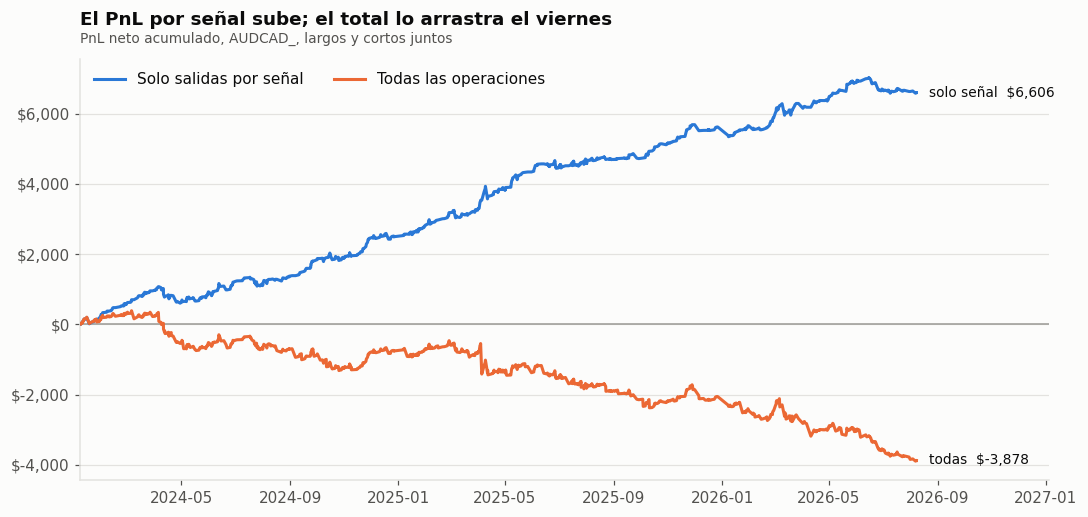

In [15]:
o = ops.sort_values("fecha_salida")
acum_todo  = o.pnl_neto_usd.cumsum()
acum_senal = o.pnl_neto_usd.where(o.tipo == "Cierre_Señal", 0).cumsum()

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.axhline(0, color=ZERO, lw=1, zorder=1)
ax.grid(True, axis="y", zorder=0)
ax.plot(o.fecha_salida, acum_senal, color=C_SENAL,   lw=2, zorder=3, label="Solo salidas por señal")
ax.plot(o.fecha_salida, acum_todo,  color=C_VIERNES, lw=2, zorder=3, label="Todas las operaciones")

# Etiquetas directas al final de cada linea, en tinta
for serie, color, texto in ((acum_senal, C_SENAL, "solo señal"),
                            (acum_todo, C_VIERNES, "todas")):
    ax.annotate(f"{texto}  ${serie.iloc[-1]:,.0f}",
                xy=(o.fecha_salida.iloc[-1], serie.iloc[-1]),
                xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK,
                path_effects=None)

ax.yaxis.set_major_formatter(usd)
ax.set_xlim(o.fecha_salida.min(), o.fecha_salida.max() + pd.Timedelta(days=150))
ax.legend(loc="upper left", ncols=2)
titular(ax, "El PnL por señal sube; el total lo arrastra el viernes",
        "PnL neto acumulado, AUDCAD_, largos y cortos juntos")
plt.tight_layout(); plt.show()

## 2. Atribucion

El mismo hecho como magnitud: cuanto aporta cada tipo de salida al resultado final.

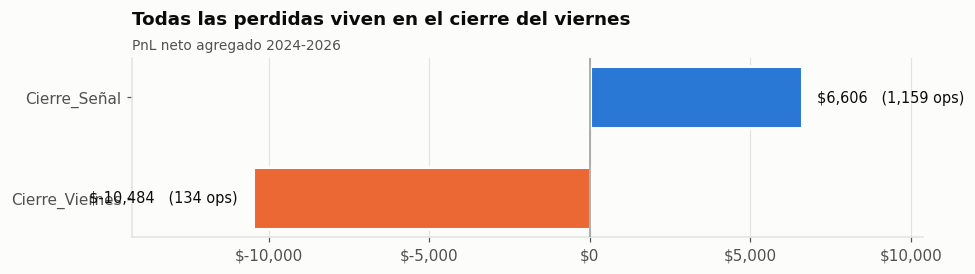

In [16]:
tot = (ops.groupby("tipo").pnl_neto_usd.sum()
          .reindex(["Cierre_Señal", "Cierre_Viernes"]))
n   = ops.groupby("tipo").size().reindex(tot.index)

fig, ax = plt.subplots(figsize=(9, 2.6))
colores = [C_SENAL, C_VIERNES]
barras = ax.barh(tot.index.astype(str), tot.values, color=colores,
                 height=.62, zorder=3)
for b in barras:
    b.set_linewidth(2); b.set_edgecolor(SURFACE)   # separador de 2px contra la superficie

ax.axvline(0, color=ZERO, lw=1, zorder=4)
ax.grid(True, axis="x", zorder=0)
for tipo, v, c in zip(tot.index, tot.values, n.values):
    ax.annotate(f"${v:,.0f}   ({c:,} ops)",
                xy=(v, tipo), xytext=(10 if v > 0 else -10, 0),
                textcoords="offset points", va="center",
                ha="left" if v > 0 else "right", fontsize=9.5, color=INK)
ax.xaxis.set_major_formatter(usd)
ax.margins(x=.22)
ax.invert_yaxis()
titular(ax, "Todas las perdidas viven en el cierre del viernes",
        "PnL neto agregado 2024-2026")
plt.tight_layout(); plt.show()

## 3. Por que el viernes pierde casi siempre

Una posicion sigue abierta el viernes por la noche *precisamente porque* la señal de
reversion nunca se disparo: el precio no volvio. Todo lo que si revirtio ya se cerro
antes. El cubo del viernes es, por construccion, una seleccion de posiciones que no
revirtieron. No es un sesgo del backtest — es lo que esa seleccion tiene que parecer.

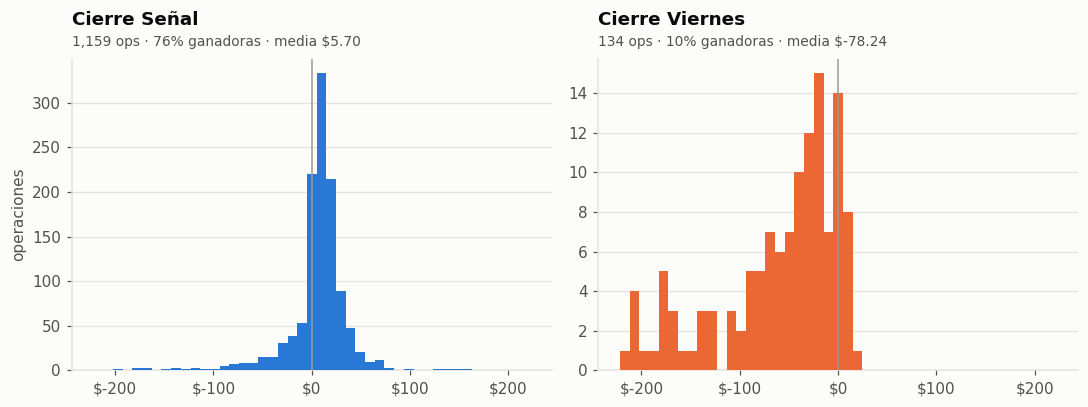

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
lim = np.percentile(np.abs(ops.pnl_neto_usd), 99)
bins = np.linspace(-lim, lim, 46)

for ax, (tipo, color) in zip(axes, (("Cierre_Señal", C_SENAL),
                                    ("Cierre_Viernes", C_VIERNES))):
    s = ops.loc[ops.tipo == tipo, "pnl_neto_usd"]
    ax.grid(True, axis="y", zorder=0)
    ax.hist(s, bins=bins, color=color, zorder=3)
    ax.axvline(0, color=ZERO, lw=1, zorder=4)
    ax.xaxis.set_major_formatter(usd)
    ganan = (s > 0).mean() * 100
    titular(ax, tipo.replace("_", " "),
            f"{len(s):,} ops · {ganan:.0f}% ganadoras · media ${s.mean():,.2f}")

axes[0].set_ylabel("operaciones")
plt.tight_layout(); plt.show()

## 4. No es una mala racha

Si las perdidas del viernes fueran unas pocas semanas malas, la curva tendria escalones.
Baja de forma sostenida durante los tres años.

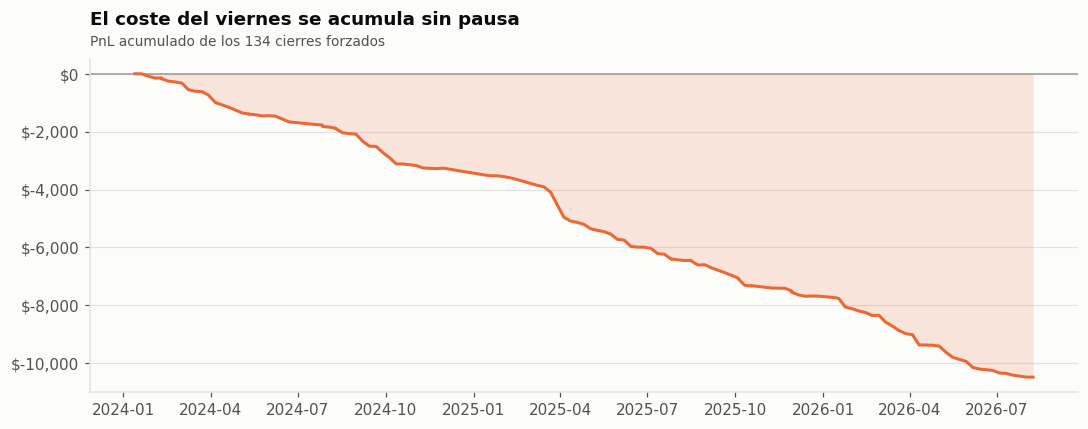

In [18]:
v = ops[ops.tipo == "Cierre_Viernes"].sort_values("fecha_salida")

fig, ax = plt.subplots(figsize=(10, 4))
ax.grid(True, axis="y", zorder=0)
ax.axhline(0, color=ZERO, lw=1, zorder=1)
ax.fill_between(v.fecha_salida, v.pnl_neto_usd.cumsum(), 0,
                color=C_VIERNES, alpha=.16, zorder=2, linewidth=0)
ax.plot(v.fecha_salida, v.pnl_neto_usd.cumsum(), color=C_VIERNES, lw=2, zorder=3)
ax.yaxis.set_major_formatter(usd)
titular(ax, "El coste del viernes se acumula sin pausa",
        f"PnL acumulado de los {len(v)} cierres forzados")
plt.tight_layout(); plt.show()

## 5. Cuanto tiempo aguantan

Cada punto es una operacion. Las salidas del viernes se agrupan abajo: son las que
llevaban mas tiempo abiertas sin revertir.

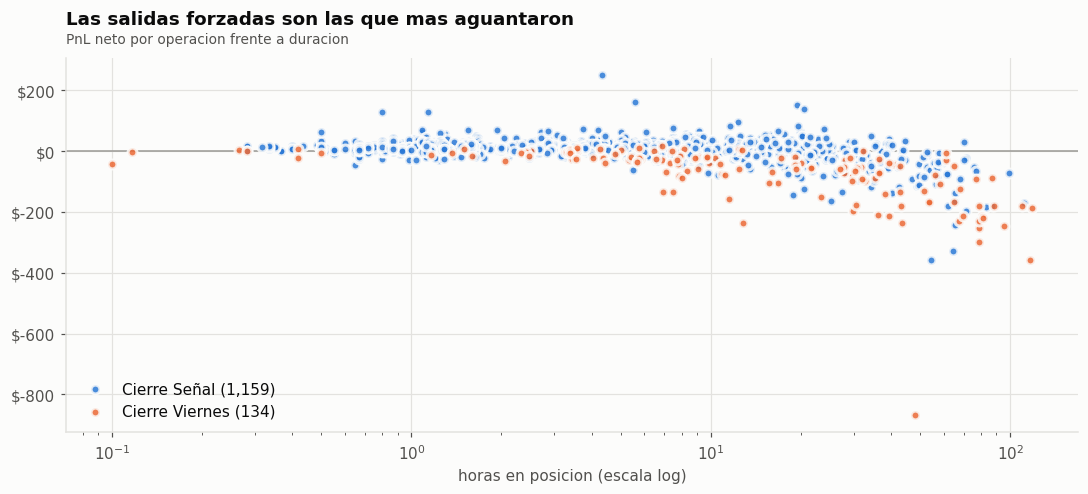

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.grid(True, zorder=0)
ax.axhline(0, color=ZERO, lw=1, zorder=1)
for tipo, color, z in (("Cierre_Señal", C_SENAL, 2), ("Cierre_Viernes", C_VIERNES, 3)):
    s = ops[ops.tipo == tipo]
    ax.scatter(s.dur_h, s.pnl_neto_usd, s=34, color=color, zorder=z,
               edgecolor=SURFACE, linewidth=2, alpha=.85,   # anillo de 2px al solaparse
               label=f"{tipo.replace('_',' ')} ({len(s):,})")
ax.set_xscale("log")
ax.set_xlabel("horas en posicion (escala log)")
ax.yaxis.set_major_formatter(usd)
ax.legend(loc="lower left")
titular(ax, "Las salidas forzadas son las que mas aguantaron",
        "PnL neto por operacion frente a duracion")
plt.tight_layout(); plt.show()

## 6. Entradas por dia de la semana

Rastro del bug del calentamiento: antes de corregirlo el buffer se media en minutos
naturales y los fines de semana no aportan filas M1, asi que la semana no empezaba a
operar hasta el miercoles. Los lunes pasaron de 23 a 320 entradas en tres años.

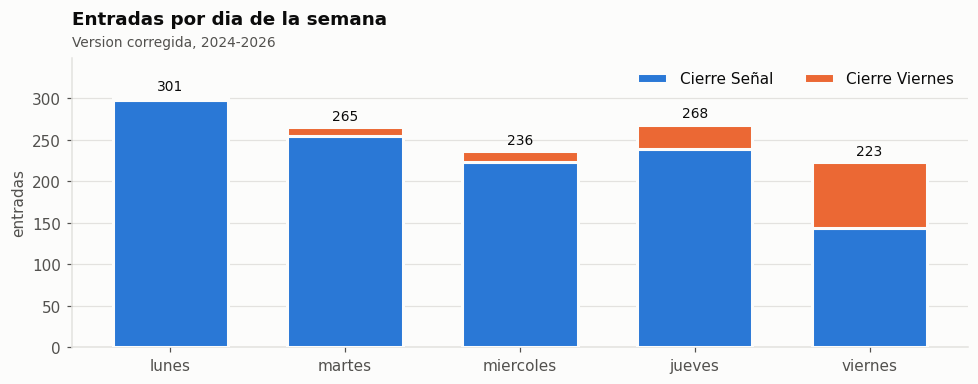

In [20]:
DIAS = ["lunes", "martes", "miercoles", "jueves", "viernes"]
por_dia = (ops.groupby(["dia_ent", "tipo"]).size().unstack(fill_value=0)
             .reindex(range(5), fill_value=0))

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.grid(True, axis="y", zorder=0)
abajo = np.zeros(5)
for tipo, color in (("Cierre_Señal", C_SENAL), ("Cierre_Viernes", C_VIERNES)):
    vals = por_dia.get(tipo, pd.Series(0, index=range(5))).values
    b = ax.bar(DIAS, vals, bottom=abajo, color=color, zorder=3, width=.66,
               label=tipo.replace("_", " "))
    for r in b:
        r.set_linewidth(2); r.set_edgecolor(SURFACE)   # separador de 2px entre segmentos
    abajo = abajo + vals

for x, total in enumerate(abajo):
    ax.annotate(f"{int(total)}", xy=(x, total), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=9, color=INK)
ax.set_ylabel("entradas")
ax.legend(loc="upper right", ncols=2)
ax.margins(y=.16)
titular(ax, "Entradas por dia de la semana", "Version corregida, 2024-2026")
plt.tight_layout(); plt.show()

## 7. ¿Y si no cerraramos el viernes?

La comparacion obvia. Ojo: **no es la del backtest antiguo**. Aquel no aguantaba las
posiciones, las *descartaba* — su PnL nunca se contabilizaba. Aguantar es otra cosa,
y hay que medirla aparte.

Contrafactual sobre las mismas 130 posiciones: se toma cada una en el momento del
cierre forzado y se sigue con las barras M1 de la semana siguiente.

Requiere `data/AUDCAD__M1.parquet` (lo genera `dump_m1.py` con el python de wine).

In [21]:
M1 = os.path.join("data", "AUDCAD__M1.parquet")
CONTRACT_SIZE = 100_000

m1 = pd.read_parquet(M1).sort_index()
viernes = ops[ops.tipo == "Cierre_Viernes"]

filas = []
for _, t in viernes.iterrows():
    w = m1.loc[t.fecha_salida : t.fecha_salida + pd.Timedelta(days=7)]
    if len(w) < 2:
        continue
    w = w.iloc[1:]                                    # primera barra tras el cierre
    pnl = (w.bid - t.precio_entrada) if t.lado == "LONG" else (t.precio_entrada - w.ask)
    filas.append(dict(lotes=t.lotes, real=t.pnl_price,
                      lunes=pnl.iloc[0], fin=pnl.iloc[-1],
                      mejor=pnl.max(), peor=pnl.min(),
                      recupera=bool((pnl >= 0).any()),
                      gap_contra=bool(pnl.iloc[0] < t.pnl_price)))
cf = pd.DataFrame(filas)
en_usd = lambda col: (cf[col] * CONTRACT_SIZE * cf.lotes).sum()

escenarios = pd.Series({
    "Cerrar el viernes (real)":       en_usd("real"),
    "Aguantar al lunes":              en_usd("lunes"),
    "Aguantar la semana siguiente":   en_usd("fin"),
})
techo, suelo = en_usd("mejor"), en_usd("peor")

print(f"{len(cf)} posiciones seguidas a la semana siguiente")
print(f"vuelven a break-even en algun momento : {cf.recupera.sum()}/{len(cf)}"
      f" ({100*cf.recupera.mean():.0f}%)")
print(f"el gap del fin de semana va en contra : {cf.gap_contra.sum()}/{len(cf)}")
escenarios.round(0)

134 posiciones seguidas a la semana siguiente
vuelven a break-even en algun momento : 92/134 (69%)
el gap del fin de semana va en contra : 67/134


Cerrar el viernes (real)       -10406.0
Aguantar al lunes              -10404.0
Aguantar la semana siguiente    -9655.0
dtype: float64

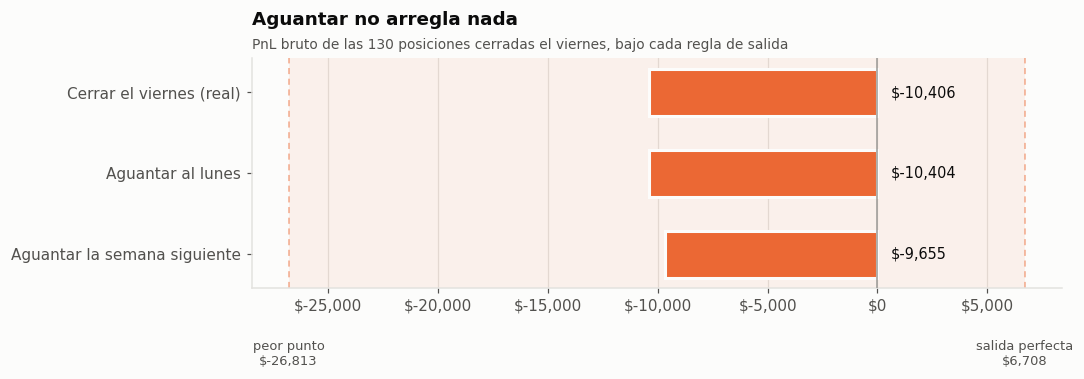

In [22]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.grid(True, axis="x", zorder=0)

# Rango alcanzable durante la semana siguiente, como banda de fondo
ax.axvspan(suelo, techo, color=C_VIERNES, alpha=.08, zorder=1, linewidth=0)
for x, etq in ((suelo, "peor punto"), (techo, "salida perfecta")):
    ax.axvline(x, color=C_VIERNES, lw=1, ls=(0, (4, 3)), alpha=.55, zorder=2)
    # Bajo el eje, en fraccion de ejes: no choca con el subtitulo
    ax.annotate(f"{etq}\n${x:,.0f}",
                xy=(x, 0), xycoords=("data", "axes fraction"),
                xytext=(0, -34), textcoords="offset points",
                ha="center", va="top", fontsize=8.5, color=INK_2,
                annotation_clip=False)

barras = ax.barh(escenarios.index.astype(str), escenarios.values,
                 color=C_VIERNES, height=.58, zorder=3)
for b in barras:
    b.set_linewidth(2); b.set_edgecolor(SURFACE)

# Valores en tinta y en el hueco a la derecha del cero, no sobre la barra
for etq, val in escenarios.items():
    ax.annotate(f"${val:,.0f}", xy=(0, etq), xytext=(9, 0),
                textcoords="offset points", ha="left", va="center",
                fontsize=9.5, color=INK)

ax.axvline(0, color=ZERO, lw=1, zorder=4)
ax.xaxis.set_major_formatter(usd)
ax.invert_yaxis()
titular(ax, "Aguantar no arregla nada",
        "PnL bruto de las 130 posiciones cerradas el viernes, bajo cada regla de salida")
fig.subplots_adjust(bottom=.3)
plt.show()

**Lo que dice esta grafica.** Aguantar al lunes da practicamente lo mismo que cerrar
(el gap del fin de semana va en contra la mitad de las veces, asi que se compensa), y
aguantar la semana entera sale *peor*. La reversion existe — el 71% de las posiciones
tocan break-even en algun momento de la semana siguiente — pero capturarla exige un
timing casi perfecto, y el suelo del rango enseña el riesgo de cola de quedarse dentro.

Ademas esto es un contrafactual sobre esas 130 posiciones, no un backtest completo sin
cierre de viernes: si aguantas, la posicion abierta bloquea entradas nuevas la semana
siguiente y la secuencia de operaciones cambia entera. Tampoco descuenta el swap extra
de aguantar, que empeoraria las dos filas de abajo.

Conclusion practica: el problema no es *cuando* se cierra, sino que estas posiciones se
abren y no revierten a tiempo. La palanca esta antes — filtrar la entrada o cortar la
perdida pronto — no en mover la salida hacia adelante.

## 8. Cuanto llego a perder cada operacion

MAE (maximum adverse excursion): lo mas en contra que estuvo cada posicion antes de
cerrarse, en pips. Es la "perdida flotante" maxima que aguanto cada entrada.

Izquierda: cada operacion como un punto. Derecha: la distribucion acumulada, que es la
forma honesta de comparar dos grupos de tamano muy distinto (1.159 frente a 134).

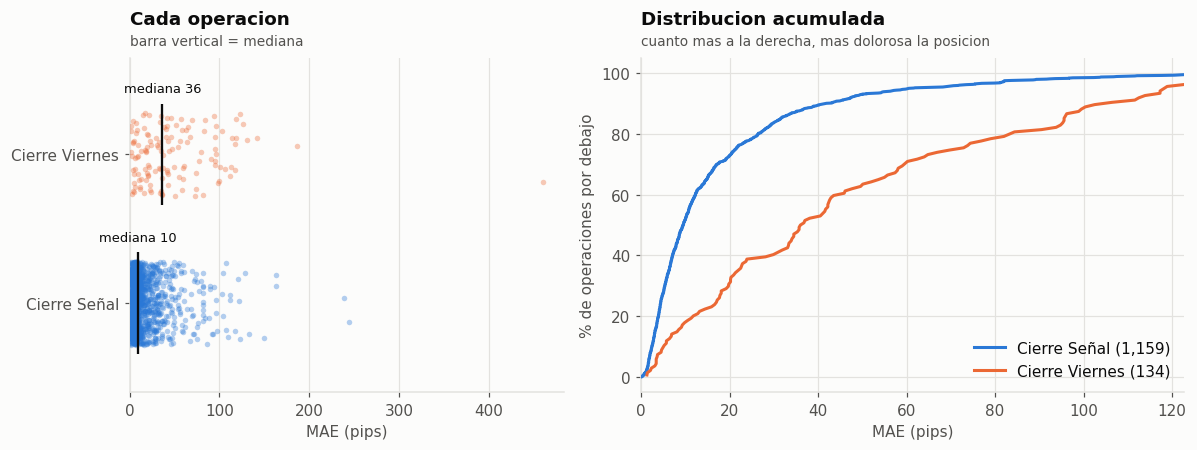

grupo                n   mediana     p75     p90      max
Cierre Señal      1159       9.5    21.4    42.1    243.8
Cierre Viernes     134      36.4    72.1   105.2    460.4


In [23]:
ops["mae_pips"] = ops.mae_price * 10_000
grupos = (("Cierre_Señal", C_SENAL), ("Cierre_Viernes", C_VIERNES))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2),
                               gridspec_kw={"width_ratios": [1, 1.25]})
rng = np.random.default_rng(0)

# --- cada operacion como un punto, con dispersion vertical para verlas todas
for y, (tipo, color) in enumerate(grupos):
    s = ops.loc[ops.tipo == tipo, "mae_pips"]
    ax1.scatter(s, y + rng.uniform(-.28, .28, len(s)), s=13, color=color,
                alpha=.35, linewidth=0, zorder=3)
    ax1.annotate(f"mediana {s.median():.0f}", xy=(s.median(), y + .42),
                 ha="center", fontsize=8.5, color=INK)
    ax1.vlines(s.median(), y - .34, y + .34, color=INK, lw=1.5, zorder=4)
ax1.set_yticks(range(len(grupos)))
ax1.set_yticklabels([t.replace("_", " ") for t, _ in grupos])
ax1.set_xlabel("MAE (pips)")
ax1.grid(True, axis="x", zorder=0)
ax1.set_xlim(left=0)
ax1.set_ylim(-0.6, len(grupos) - 0.35)   # holgura para las etiquetas de mediana
titular(ax1, "Cada operacion", "barra vertical = mediana")

# --- distribucion acumulada
for tipo, color in grupos:
    s = np.sort(ops.loc[ops.tipo == tipo, "mae_pips"].values)
    ax2.plot(s, np.arange(1, len(s) + 1) / len(s) * 100, color=color, lw=2,
             zorder=3, label=f"{tipo.replace('_',' ')} ({len(s):,})")
ax2.grid(True, zorder=0)
ax2.set_xlabel("MAE (pips)")
ax2.set_ylabel("% de operaciones por debajo")
ax2.set_xlim(0, np.percentile(ops.mae_pips, 99))
ax2.legend(loc="lower right")
titular(ax2, "Distribucion acumulada", "cuanto mas a la derecha, mas dolorosa la posicion")
plt.tight_layout(); plt.show()

print(f"{'grupo':<16}{'n':>6}{'mediana':>10}{'p75':>8}{'p90':>8}{'max':>9}")
for tipo, _ in grupos:
    s = ops.loc[ops.tipo == tipo, "mae_pips"]
    print(f"{tipo.replace('_',' '):<16}{len(s):>6}{s.median():>10.1f}{s.quantile(.75):>8.1f}"
          f"{s.quantile(.90):>8.1f}{s.max():>9.1f}")

## 9. Simulacion: no abrir posiciones los viernes

A diferencia de "quedarse solo con las salidas por señal", esta regla **si es operable**:
el dia de la semana se conoce en el momento de entrar. Lo que si es sesgado es haberla
elegido despues de ver los datos, asi que hay que leerla como una cota, no como un
resultado fuera de muestra.

No basta con sumar el PnL de las operaciones que quedan: el tamano de cada posicion
depende del balance corriente, asi que al quitar operaciones cambia el lotaje de todas
las siguientes. Se vuelve a pasar la contabilidad completa, con el mismo modelo de
reserva que usa `_contabilizar`.

In [24]:
APALANCAMIENTO = 2
CONTRACT_SIZE  = 100_000
CAPITAL        = 10_000.0

def recontabilizar(trades, capital=CAPITAL):
    """Replica _contabilizar: lotaje segun balance corriente y reserva de ganancias."""
    bal, res, filas = capital, 0.0, []
    for _, r in trades.sort_values("fecha_salida").iterrows():
        lotes = (bal * APALANCAMIENTO) / (r.precio_entrada * CONTRACT_SIZE)
        bruto = r.pnl_price * CONTRACT_SIZE * lotes
        # el swap es proporcional al lotaje, se reescala desde el original
        swap  = r.swap_usd * (lotes / r.lotes) if r.lotes else 0.0
        neto  = bruto + swap                      # comision_rt = 0 en este simbolo
        bal  += neto
        if bal > capital:
            res += bal - capital; bal = capital
        elif bal < capital and res > 0:
            t = min(capital - bal, res); res -= t; bal += t
        filas.append({"fecha_salida": r.fecha_salida, "neto": neto,
                      "patrimonio": bal + res, "lotes": lotes})
    return pd.DataFrame(filas)

# sanidad: sin filtrar debe reproducir el patrimonio que reporto el backtest
for lado in ("LONG", "SHORT"):
    sub = ops[ops.lado == lado]
    for anio, g in sub.groupby("anio"):
        rec = recontabilizar(g)
        real = g.sort_values("fecha_salida").patrimonio_total.iloc[-1]
        assert abs(rec.patrimonio.iloc[-1] - real) < 0.01, (lado, anio)
print("sanidad: la contabilidad replicada coincide con la del backtest\n")

filas = []
for anio in sorted(ops.anio.unique()):
    for lado in ("LONG", "SHORT"):
        g = ops[(ops.anio == anio) & (ops.lado == lado)]
        sin_v = g[g.dia_ent != 4]
        r_all, r_sin = recontabilizar(g), recontabilizar(sin_v)
        filas.append({
            "anio": anio, "lado": lado,
            "ops": len(g), "ops_sin_viernes": len(sin_v),
            "ret_todas_%":     round(100 * (r_all.patrimonio.iloc[-1] / CAPITAL - 1), 2),
            "ret_sin_viernes_%": round(100 * (r_sin.patrimonio.iloc[-1] / CAPITAL - 1), 2),
        })
sim = pd.DataFrame(filas)
sim["delta_pp"] = (sim["ret_sin_viernes_%"] - sim["ret_todas_%"]).round(2)
sim

sanidad: la contabilidad replicada coincide con la del backtest



,anio,lado,ops,ops_sin_viernes,ret_todas_%,ret_sin_viernes_%,delta_pp
0,2024,LONG,274,239,-2.65,-0.08,2.57
1,2024,SHORT,234,193,-4.90,-6.95,-2.05
2,2025,LONG,257,217,-11.13,-9.18,1.95
3,2025,SHORT,263,207,-1.91,1.45,3.36
4,2026,LONG,151,120,-4.52,-0.94,3.58
5,2026,SHORT,114,94,-13.68,-12.63,1.05


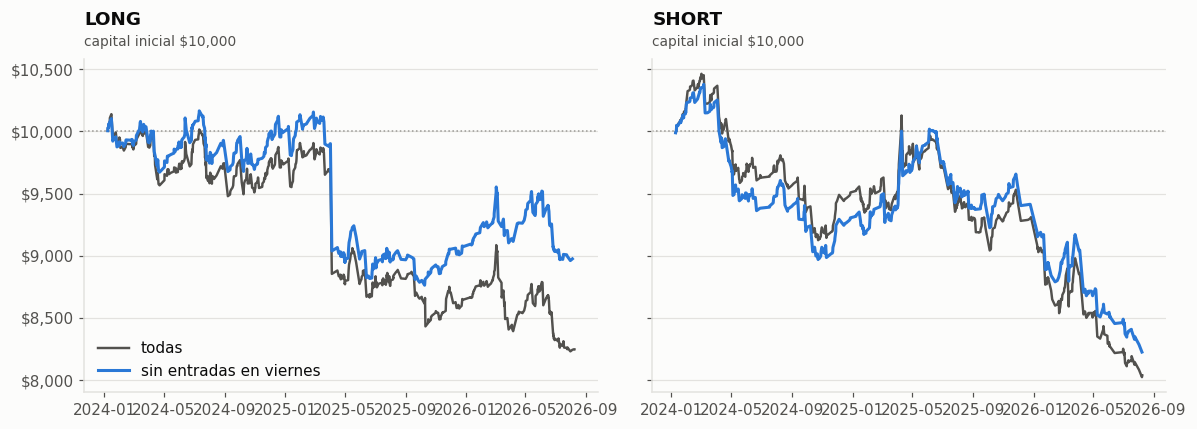

operaciones eliminadas (entradas en viernes): 223 de 1293
patrimonio final, ambos lados   todas: $16,285   sin viernes: $17,201
sobre $20,000 de capital  ->  -18.57%  vs  -14.00%


In [25]:
C_BASE, C_VAR = INK_2, C_SENAL

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, lado in zip(axes, ("LONG", "SHORT")):
    g = ops[ops.lado == lado]
    for etq, datos, color, ancho in (("todas", g, C_BASE, 1.6),
                                     ("sin entradas en viernes", g[g.dia_ent != 4], C_VAR, 2)):
        r = recontabilizar(datos)
        ax.plot(r.fecha_salida, r.patrimonio, color=color, lw=ancho, zorder=3, label=etq)
    ax.axhline(CAPITAL, color=ZERO, lw=1, ls=":", zorder=1)
    ax.grid(True, axis="y", zorder=0)
    ax.yaxis.set_major_formatter(usd)
    titular(ax, lado, f"capital inicial ${CAPITAL:,.0f}")
axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

tot_a = sum(recontabilizar(ops[ops.lado == l]).patrimonio.iloc[-1] for l in ("LONG","SHORT"))
tot_s = sum(recontabilizar(ops[(ops.lado == l) & (ops.dia_ent != 4)]).patrimonio.iloc[-1]
            for l in ("LONG","SHORT"))
quitadas = (ops.dia_ent == 4).sum()
print(f"operaciones eliminadas (entradas en viernes): {quitadas} de {len(ops)}")
print(f"patrimonio final, ambos lados   todas: ${tot_a:,.0f}   sin viernes: ${tot_s:,.0f}")
print(f"sobre ${2*CAPITAL:,.0f} de capital  ->  {100*(tot_a/(2*CAPITAL)-1):+.2f}%  vs  {100*(tot_s/(2*CAPITAL)-1):+.2f}%")

## Como leerlo

- Las salidas por señal son **rentables** y siguieron siendolo tras la correccion.
- El cierre del viernes se lleva mas de lo que gana la señal, con una tasa de acierto
  de un digito. Ese es el resultado neto negativo, entero.
- El cierre del viernes **no es invencion del backtest corregido**: el optimizador ya
  lo modela (`tester.get_vector_buys` añade una salida en la ultima vela del viernes)
  y el bot en vivo ya manda su `Cierre_Viernes`. El backtest anterior era el unico de
  los tres que lo hacia mal, y por eso parecia tener ventaja.

Asi que la pregunta ya no es si la señal sirve, sino **que hacer con las posiciones que
no revierten dentro de la semana**. La seccion 7 descarta la opcion mas obvia: aguantar
no las salva. Quedan:

1. Un **stop-loss** que corte a los perdedores antes de que lleguen al viernes. Es lo
   primero a probar: ataca directamente el unico cubo que pierde, y el backtest ya trae
   soporte de stop loss desde el commit `5f4ef01`.
2. Un **filtro de entrada** que evite abrir tan cerca del cierre semanal — las salidas
   forzadas son las que mas tiempo aguantaron, asi que muchas se abren tarde.
3. Alinear la rejilla de velas entre optimizador y ejecutor y **reoptimizar**. Los
   parametros actuales se eligieron sobre una rejilla que el ejecutor no reproduce, asi
   que para el sistema que corre son practicamente arbitrarios.

Cualquiera de las tres se mide volviendo a correr el backtest y mirando la grafica 2: lo
que hay que conseguir es encoger la barra naranja.